# Test State Injection Experiment

Tests the State Injection protocols (corner and middle) for Rotated Surface Code across different distances and injected states (|0⟩ and |+⟩).

In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.state_injection import StateInjectionExperiment

## 1. Build circuits (no noise)

Build injection circuits for different Distance, Protocol (corner/middle), and inject_state (Z->|0⟩, X->|+⟩).

In [2]:
results = []
for d in [3, 5]:
    for protocol in ['corner', 'middle']:
        for inject_state in ['Z', 'X']:
            exp = StateInjectionExperiment(
                distance=d,
                rounds=2,
                injection_protocol=protocol,
                inject_state=inject_state,
                noise_params=None,
            )
            circ = exp.build()
            results.append({
                'distance': d,
                'protocol': protocol,
                'inject_state': inject_state,
                'circuit': circ,
                'num_ops': len(circ),
            })
            print(f'd={d} {protocol} {inject_state}: {len(circ)} ops')

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner Z: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner X: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle Z: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle X: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner Z: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner X: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle Z: 92 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle X: 92 ops


## 2. Verify correctness by sampling (noiseless)

With zero noise, the circuit is deterministic. Sample multiple shots and check that the logical observable matches the injected state.

In [3]:
n_shots = 100
all_pass = True
for r in results:
    circ = r['circuit']
    sampler = circ.compile_detector_sampler()
    dets, obs = sampler.sample(shots=n_shots, separate_observables=True)
    # obs shape: (n_shots, n_observables). For single logical, obs[:, 0]
    # Ideal |0⟩ (Z) and |+⟩ (X) both yield observable 0 in noiseless case
    if not np.all(obs == 0):
        all_pass = False
        print(f"FAIL d={r['distance']} {r['protocol']} {r['inject_state']}: obs={obs[:, 0][:5]}...")
    else:
        print(f"OK d={r['distance']} {r['protocol']} {r['inject_state']}: {n_shots} shots, obs=0 (correct)")

print("\n" + ("All tests passed!" if all_pass else "Some tests failed."))

OK d=3 corner Z: 100 shots, obs=0 (correct)
OK d=3 corner X: 100 shots, obs=0 (correct)
OK d=3 middle Z: 100 shots, obs=0 (correct)
OK d=3 middle X: 100 shots, obs=0 (correct)
OK d=5 corner Z: 100 shots, obs=0 (correct)
OK d=5 corner X: 100 shots, obs=0 (correct)
OK d=5 middle Z: 100 shots, obs=0 (correct)
OK d=5 middle X: 100 shots, obs=0 (correct)

All tests passed!


## 3. Circuit diagram (example: d=3, corner, Z)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...


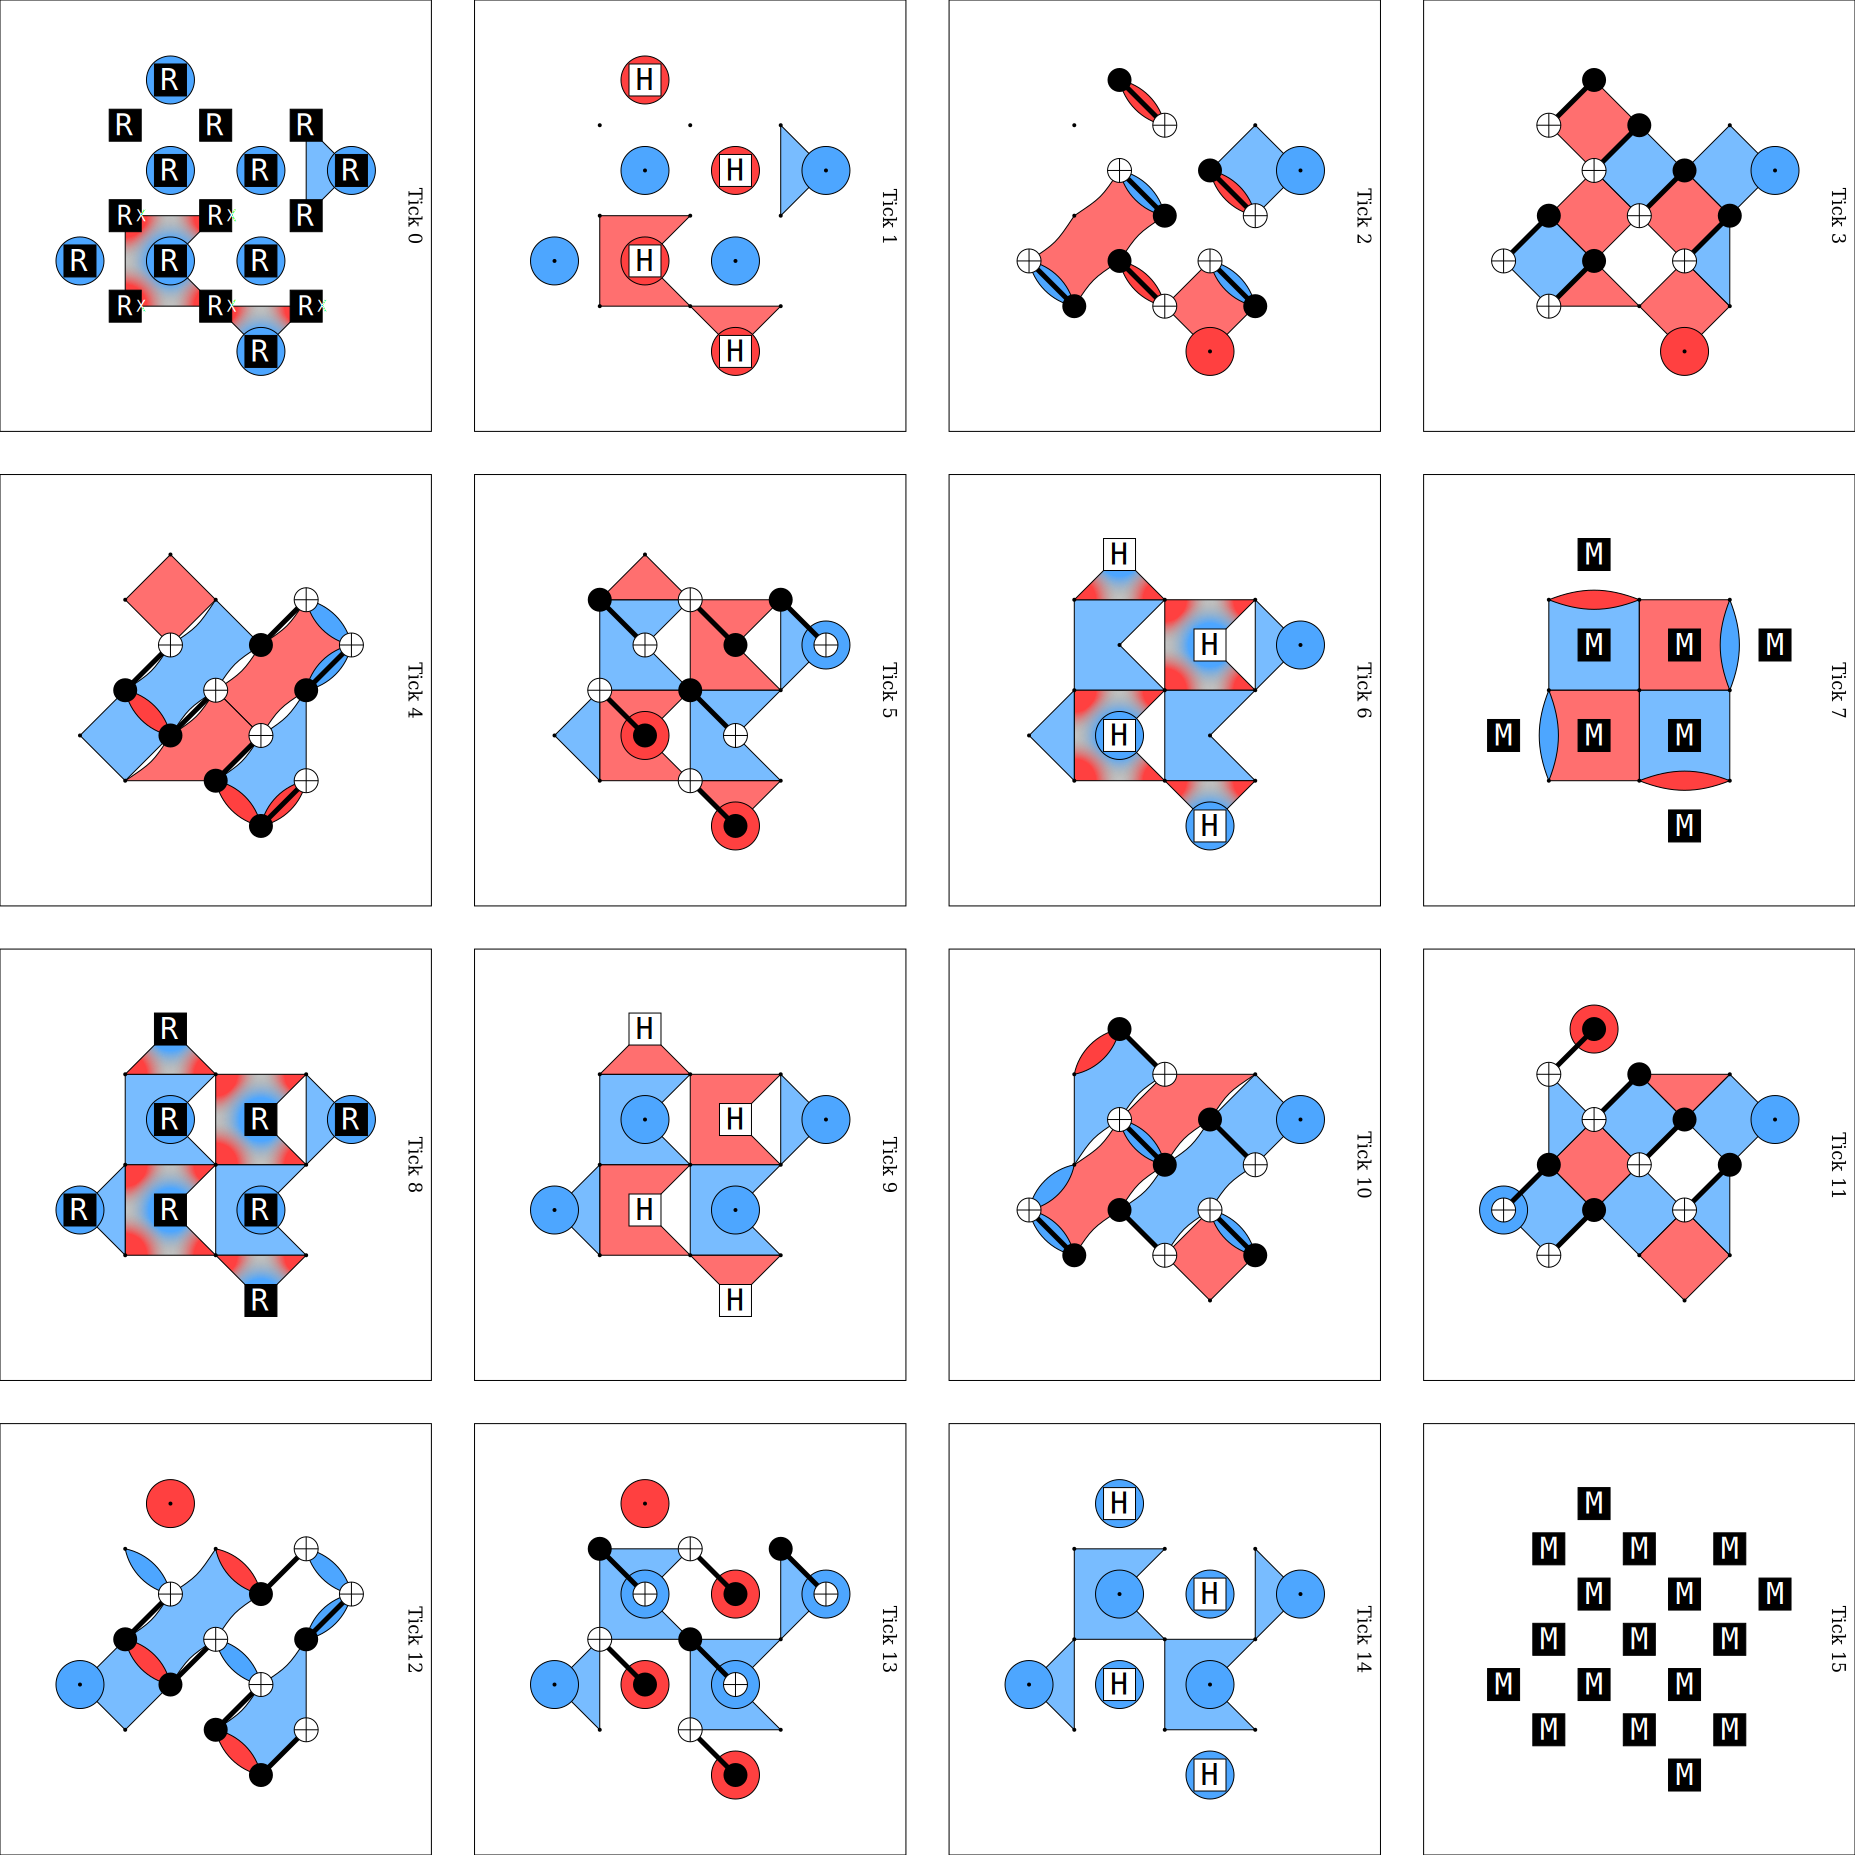

In [4]:
exp = StateInjectionExperiment(distance=3, rounds=2, injection_protocol='corner', inject_state='Z')
circ = exp.build()
circ.without_noise().diagram('detslice-with-ops-svg')

In [5]:
circ

stim.Circuit('''
    QUBIT_COORDS(2, 0) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(3, 1) 2
    QUBIT_COORDS(5, 1) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(6, 2) 5
    QUBIT_COORDS(4, 2) 6
    QUBIT_COORDS(1, 3) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(5, 3) 9
    QUBIT_COORDS(0, 4) 10
    QUBIT_COORDS(4, 4) 11
    QUBIT_COORDS(2, 4) 12
    QUBIT_COORDS(1, 5) 13
    QUBIT_COORDS(3, 5) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(4, 6) 16
    RX 7 8 13 14 15
    R 1 2 3 9 0 4 5 6 10 11 12 16
    TICK[SE_start]
    H 0 6 12 16
    TICK
    CX 0 2 6 9 12 14 8 4 13 10 15 11
    TICK
    CX 0 1 6 8 12 13 2 4 7 10 9 11
    TICK
    CX 6 3 12 8 16 15 7 4 9 5 14 11
    TICK
    CX 6 2 12 7 16 14 1 4 3 5 8 11
    TICK
    H 0 6 12 16
    TICK
    M 0 4 5 6 10 11 12 16
    DETECTOR(6, 2, 0) rec[-6]
    DETECTOR(2, 4, 0) rec[-2]
    DETECTOR(4, 6, 0) rec[-1]
    REPEAT 1 {
        TICK
        R 0 4 5 6 10 11 12 16
        TICK[SE_start]
        H 0 6 12 16
        TICK
        CX 0 2 6 9 